# Calibration Study — Pima Indians Diabetes

**Assignment 2 — Calibration of Probabilities** (SML, Univ. of Milan)

## Why this dataset
768 samples, 8 clinical features, binary target (1 = tested_positive, ~35% positive rate), fetched via
`sklearn.datasets.fetch_openml(data_id=37)` (the OpenML mirror of the UCI Pima Indians Diabetes dataset).
Compared to the breast-cancer dataset, this problem is **noisier and less separable** (test accuracy
tops out around 70-75% for these model classes) and a bit more imbalanced. This gives us a genuine
contrast case: we expect **more** miscalibration here, and a better opportunity for Platt scaling /
isotonic regression to actually help. (Quantified in the "What to notice" cell below: this
expectation only partly holds — the models are less sharp here, but neither calibrator improves
log-loss over the uncalibrated baseline.)

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.calibration import PlattScaling, IsotonicRegressionPAVA
from src.metrics import evaluate_probs
from src.plotting import plot_reliability_comparison
from src.experiment import train_base_models, SEED


In [2]:
from src.datasets import load_diabetes_dataset, split_train_calib_test
from sklearn.preprocessing import StandardScaler

X, y, name, description = load_diabetes_dataset()
print(description)

splits = split_train_calib_test(X, y, seed=SEED)
X_train, y_train = splits["X_train"], splits["y_train"]
X_calib, y_calib = splits["X_calib"], splits["y_calib"]
X_test, y_test = splits["X_test"], splits["y_test"]

scaler = StandardScaler().fit(X_train)
X_train, X_calib, X_test = scaler.transform(X_train), scaler.transform(X_calib), scaler.transform(X_test)

print(f"train={len(y_train)}  calib={len(y_calib)}  test={len(y_test)}")
print(f"positive rate  train={y_train.mean():.3f}  calib={y_calib.mean():.3f}  test={y_test.mean():.3f}")


Pima Indians Diabetes (OpenML id=37, UCI mirror): 768 samples, 8 features, binary (1=tested_positive), ~35% positive rate, noisier and less separable than the breast-cancer dataset.
train=460  calib=154  test=154
positive rate  train=0.350  calib=0.351  test=0.344


Note: raw zeros in `plas`/`pres`/`skin`/`insu`/`mass` are treated as missing (a documented quirk of this dataset) and median-imputed using statistics from the **training** split only — see `src/datasets.py`.

In [3]:
models = train_base_models(X_train, y_train, seed=SEED)
models


{'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
 'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)}

In [4]:
results = []
prob_variants_by_model = {}

for model_name, model in models.items():
    p_calib_raw = model.predict_proba(X_calib)[:, 1]
    p_test_raw = model.predict_proba(X_test)[:, 1]

    platt = PlattScaling().fit(p_calib_raw, y_calib)
    p_test_platt = platt.predict(p_test_raw)

    isotonic = IsotonicRegressionPAVA().fit(p_calib_raw, y_calib)
    p_test_iso = isotonic.predict(p_test_raw)

    prob_variants = {"Uncalibrated": p_test_raw, "Platt": p_test_platt, "Isotonic": p_test_iso}
    prob_variants_by_model[model_name] = prob_variants

    for method_name, p in prob_variants.items():
        m = evaluate_probs(y_test, p)
        results.append({"model": model_name, "method": method_name, **m})

df_db = pd.DataFrame(results)
df_db


,model,method,accuracy,log_loss,brier_score,ece,tilt
0,LogisticRegression,Uncalibrated,0.740260,0.517886,0.174252,0.079680,-0.093676
1,LogisticRegression,Platt,0.746753,0.524148,0.174959,0.052838,-0.057615
2,LogisticRegression,Isotonic,0.675325,1.568754,0.189628,0.127194,-0.187884
3,RandomForest,Uncalibrated,0.720779,0.515474,0.175025,0.064589,-0.085414
4,RandomForest,Platt,0.720779,0.522637,0.176122,0.064902,-0.064952
5,RandomForest,Isotonic,0.733766,0.514088,0.173659,0.046400,-0.093220


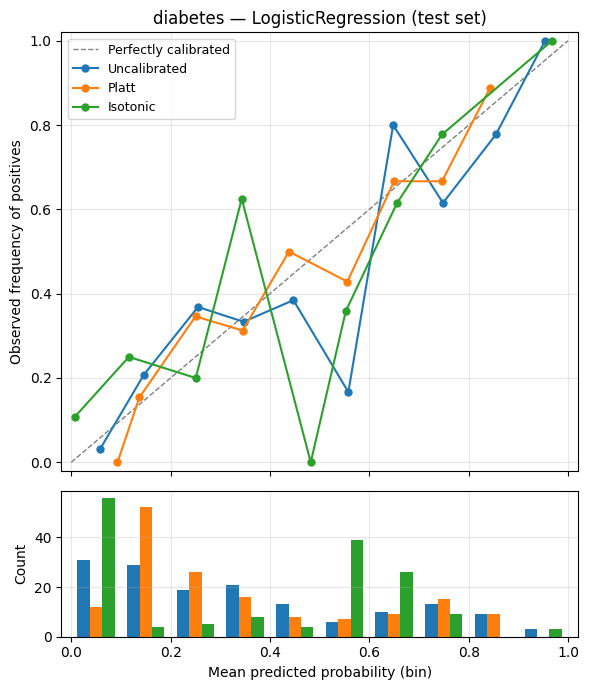

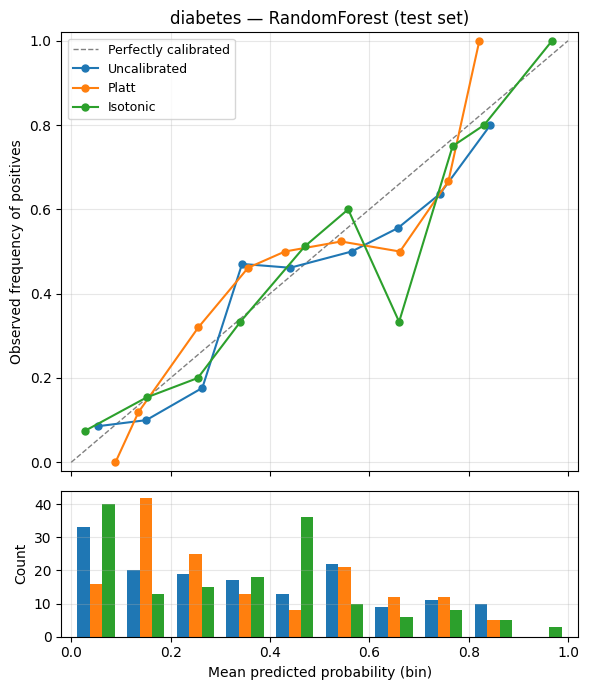

In [5]:
for model_name, prob_variants in prob_variants_by_model.items():
    plot_reliability_comparison(y_test, prob_variants, title=f"diabetes — {model_name} (test set)")
    plt.show()


## What to notice
- This is a harder, noisier problem than breast cancer, so predicted probabilities spread out more
  across the full [0, 1] range (see the histogram panels) instead of bunching at the extremes, so
  isotonic regression does not degenerate into a hard 0/1 step function here the way it did on
  breast cancer (see notebook 1).
- **That does *not* mean isotonic regression wins here, though.** The multi-seed check in
  `03_cross_dataset_summary.ipynb` (10 random splits) shows isotonic log-loss averaging **~0.80-0.82**
  on this dataset for both models, against **~0.49** for Platt scaling and the uncalibrated baseline —
  a real, consistent gap, not just a breast-cancer artifact. An earlier draft of this notebook claimed
  the opposite ("more room for isotonic to pay off" on the noisier dataset); that claim did not survive
  contact with multi-seed evidence and has been corrected here. Brier score and ECE are much closer
  across methods on this dataset (overlapping error bars in the multi-seed plot), so the practical
  takeaway is narrower than it first looks: isotonic's extra flexibility mainly costs log-loss here,
  it does not clearly buy anything back on the other metrics.
- Compare the shape of the Random Forest curve here to Logistic Regression's: if Random Forest's curve
  bows one way and Logistic Regression's is closer to the diagonal, that is evidence for the
  "tree-ensemble averaging causes under/over-confidence" effect discussed in Niculescu-Mizil & Caruana.
- See `results/metrics/diabetes_metrics.csv` for this single split's exact numbers, and
  `03_cross_dataset_summary.ipynb` for the across-dataset comparison and the multi-seed stability check.